# Sprint 14 - Modelamiento con Álgebra Lineal (Ejercicios)

Continuamos profundizando en el estudio de herramientas basadas en **álgebra lineal**, una de las áreas matemáticas más importantes para la ciencia de datos y el aprendizaje computacional. Como hemos visto en casos anteriores, muchos de los algoritmos utilizados para analizar, transformar y modelar datos pueden interpretarse como operaciones realizadas sobre vectores y matrices.

En esta oportunidad nos enfocaremos en el **Análisis de Componentes Independientes (ICA)**, una técnica de transformación de variables que comparte ciertas similitudes con el ya conocido **PCA** pero con propósitos particularmente distintos. Ambos métodos parten de la idea de que la información contenida en un conjunto de variables puede representarse mediante nuevas dimensiones derivadas matemáticamente a partir de los datos originales. Sin embargo, mientras que el PCA busca identificar nuevas variables que expliquen la mayor cantidad posible de variabilidad presente en los datos, el **ICA** tiene como propósito exclusivo encontrar componentes independientes cuya combinación funcional genera los datos originales. 

Gracias a esta característica, el **ICA** resulta especialmente útil cuando los datos observados son en realidad combinaciones de múltiples señales o fuentes subyacentes que se encuentran mezcladas. El algoritmo intenta recuperar dichas fuentes originales a partir de las observaciones disponibles, identificando patrones independientes que contribuyen a generar los datos observados. En otras palabras, **ICA** busca responder a una pregunta muy común en análisis de datos: ¿es posible descubrir los factores que dieron origen en un principio a la información que estamos observando?

En el contexto de la ciencia de datos, el **ICA** puede utilizarse para identificar factores latentes, eliminar ruido, separar señales superpuestas y descubrir estructuras ocultas que no son evidentes en las variables originales. Por esta razón, se ha convertido en una herramienta valiosa cuando se trabaja con información compleja donde múltiples fenómenos contribuyen simultáneamente a los datos observados.

A lo largo de este caso práctico estudiaremos los fundamentos conceptuales del **ICA**, comprenderemos sus diferencias respecto al PCA y analizaremos situaciones en las que resulta conveniente utilizar una técnica u otra. De esta manera, continuaremos fortaleciendo nuestra comprensión del **álgebra lineal** aplicada al análisis de datos, incorporando una nueva herramienta para la exploración y transformación avanzada de información.

## Entendimiento del contexto

La Fiscalía de tu país se encuentra investigando un presunto caso de corrupción relacionado con la adjudicación irregular de contratos públicos. Como parte de la investigación, existen indicios de que varios funcionarios y particulares habrían participado en reuniones privadas donde se discutieron posibles acuerdos ilícitos vinculados a pagos no autorizados a cambio de favorecer determinados procesos de contratación. Sin embargo, para avanzar en el proceso judicial, las autoridades necesitan reunir evidencia objetiva que permita determinar quiénes participaron efectivamente en dichas reuniones.

Uno de los principales sospechosos del caso ha negado cualquier relación con los hechos investigados. No obstante, la Fiscalía considera que existen motivos razonables para creer que esta persona estuvo presente en una reunión clave para la investigación. Debido a la importancia del caso y a las posibles consecuencias legales asociadas, resulta fundamental disponer de evidencia técnica que permita respaldar o descartar esta hipótesis de manera rigurosa.

Como parte de las labores de inteligencia realizadas durante la investigación, las autoridades lograron instalar tres micrófonos ocultos en el lugar donde se desarrolló la reunión. Gracias a ello se obtuvieron grabaciones de aproximadamente cinco minutos de duración que contienen las conversaciones entre los asistentes. Sin embargo, la calidad del audio es moderada y las voces aparecen mezcladas entre sí debido a la ubicación de los dispositivos, el ruido ambiental y la participación simultánea de varias personas. Estas condiciones dificultan considerablemente la identificación directa de los participantes.

Ante esta situación, la Fiscalía ha decidido recurrir a técnicas avanzadas de ciencia de datos para procesar la información disponible. En particular, consideran que herramientas basadas en estadística, álgebra lineal y procesamiento de señales podrían ayudar a separar las distintas voces presentes en las grabaciones y aislar patrones que permitan comparar dichas señales con registros conocidos del sospechoso.

Por esta razón, has sido contratado para colaborar en la investigación. Tu objetivo será aplicar técnicas de análisis matemático y procesamiento de información para determinar si la voz del sospechoso se encuentra presente en las grabaciones obtenidas. Los resultados de tu trabajo podrían constituir un insumo relevante dentro del conjunto de evidencias evaluadas por la Fiscalía, contribuyendo a esclarecer los hechos investigados y apoyar el desarrollo del proceso judicial.

## Entendimiento de los datos

Importa las librerías que utilizarás incluyendo las funciones `StandardScaler` y el módulo `metrics` de **Scikit-Learn**.

In [1]:
# Cargar librerías para manipulación y visualizacion de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar librerias para modelamiento
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

La Fiscalía ha decodificado en decibeles (dB) los audios extraídos de las 3 grabaciones y los ha incorporado en la tabla [**grabaciones.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/grabaciones.csv), que debes cargar a continuación. 

In [2]:
# Cargar dataset de audios de grabacion
df_reunion = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/grabaciones.csv")

In [3]:
# Mostrar estructura de los datos
df_reunion.info()

<class 'pandas.DataFrame'>
RangeIndex: 2672 entries, 0 to 2671
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   grabacion_1  2672 non-null   float64
 1   grabacion_2  2672 non-null   float64
 2   grabacion_3  2672 non-null   float64
dtypes: float64(3)
memory usage: 62.8 KB


Este dataset contiene 2,672 filas y 3 columnas (donde cada una de ellas representa una de las grabaciones respectivamente). 

Adicional a esto, la Fiscalía también te ha compartido otra grabación en el archivo [**mensaje.txt**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/mensaje.txt) que contiene la información -igual en dB- de un audio con la voz del sospechoso. Esta grabación fue levantada en unas declaraciones en medios que realizó la persona hace un par de semanas, y que tiene una duración de alrededor un minuto descompuesto en 600 décimas de segundo.

In [4]:
# Cargar el dataset de la entrevista
df_entrevista = pd.read_table(
    "https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/mensaje.txt", 
    sep = ":", 
    header = None, 
    index_col = 0
)
df_entrevista.columns = ["db"]

In [5]:
# Mostrar estructura de los datos
df_entrevista.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   db      600 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB


Explora estos datasets a fin de conocerlos en mayor detalle.

In [6]:
# Generar muestra de los datos de las reuniones
df_reunion.sample(10)

,grabacion_1,grabacion_2,grabacion_3
937,19.333750,45.972210,32.987132
1323,24.417069,33.651845,49.788308
434,44.222452,32.163917,21.751621
1371,14.897371,47.881100,32.007412
2285,13.480529,43.904242,34.613882
1395,46.621428,26.548136,34.280330
1001,40.657537,33.826108,28.298327
2615,25.620040,40.565226,44.478906
2293,18.967869,49.173767,41.489312
2620,28.907141,27.608969,43.808059


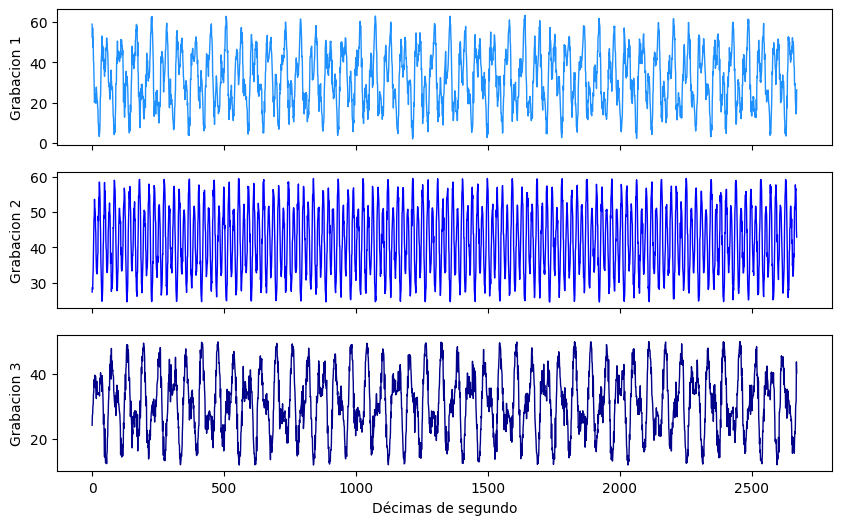

In [7]:
# Visualizar grabaciones en decibeles
fig, ax = plt.subplots(3, 1, figsize = [10,6], sharex = True)
ax[0].plot(df_reunion.index, df_reunion["grabacion_1"], color = "dodgerblue", linewidth = 1)
ax[0].set_ylabel("Grabacion 1")
ax[1].plot(df_reunion.index, df_reunion["grabacion_2"], color = "blue", linewidth = 1)
ax[1].set_ylabel("Grabacion 2") 
ax[2].plot(df_reunion.index, df_reunion["grabacion_3"], color = "darkblue", linewidth = 1)
ax[2].set_ylabel("Grabacion 3")
ax[2].set_xlabel("Décimas de segundo")
plt.show()

In [8]:
# Generar muestra de los datos
df_entrevista.sample(10)

,db
0,
171,39.703586
22,35.065435
256,44.370029
582,38.128942
402,36.447498
69,44.811585
498,37.029547
28,36.010933
525,35.203976


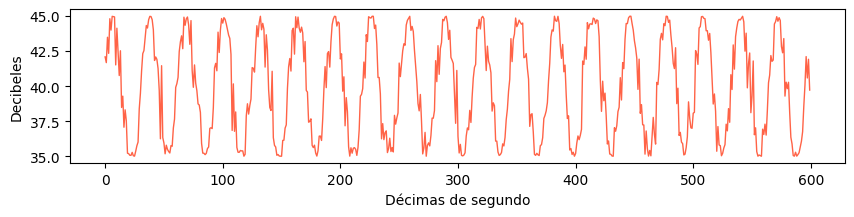

In [9]:
# Visualizar entrevista en decibeles
df_entrevista.plot(
    legend = False,
    figsize = [10,2],
    xlabel = "Décimas de segundo",
    ylabel = "Decibeles",
    color = "tomato",
    linewidth = 1
)
plt.show()

Retomando el caso en cuestión, si el sospechoso se encontró en la reunión sería lógico suponer que su voz quedó registrada en las grabaciones, aunque mezclada entre las voces de otros participantes y diversos ruidos ambientales. El desafío está entonces en buscar una manera de aislar cada una de estas fuentes de audio, y justamente para esto utilizaremos el **ICA** que se basa en una técnica de álgebra lineal llamada **descomposición singular**.

## Aplicación del ICA

El **ICA**, consiste de un proceso que combina métodos estadísticos y de álgebra lineal, a fin de extraer los componentes $c$ que mediante una combinación lineal generan las variables $x$ que son parte de un dataset estandarizado $X$. En otras palabras para toda variable $x$ del dataset, se cumple que 

$$ x = \sum_{c} \kappa_c c $$

donde $\kappa_c$ es un peso asociado al componente $c$ en principio desconocido. Además, como su nombre lo indica estos componentes son independientes entre sí, por lo cual su covarianza es 0.

Para tener una comprensión mayor del algoritmo **ICA**, conviene compararlo con el PCA. Por una parte, notemos que el segundo utiliza métodos matemáticos para combinar las variables $x$ del dataset en nuevos atributos $x_{pca}$ independientes tal que 

$$ X_{pca} = f(X) = X\cdot Q $$

En cambio, el **ICA** hace un proceso "inverso" en cuanto a que busca descomponer cada $x$ en sus componentes tal que

$$ x = f(C) = C\cdot \kappa,\quad x\in X $$

A continuación entonces, vamos a realizar paso a paso el proceso que nos permite obtener estos componentes.

### Estandarización del dataset

Como ya conoces, el PCA requiere que las variables en $X$ estén centradas con media 0. El **ICA** por su parte requiere que además su desviación estandar sea 1, o lo que es lo mismo que $X$ esté completamente estandarizado.

Estandariza por tanto tus datos de grabaciones en la reunión y guarda el resultado en la variable `X`.

In [10]:
mod_est = StandardScaler()
X = mod_est.fit_transform(df_reunion)
X = pd.DataFrame(X, columns = df_reunion.columns)
print(X.describe().round(2).loc[["mean","std"]])

      grabacion_1  grabacion_2  grabacion_3
mean         -0.0          0.0          0.0
std           1.0          1.0          1.0


### Descomposición singular para ICA

A diferencia del PCA que aplica una descomposición de vectores propios de la matriz de covarianza $\Sigma_X$, el **ICA** requiere de una descomposición de **vectores singulares** de dicha matriz tal que

$$ \Sigma_X = U\cdot \Lambda_o\cdot V $$

donde $U$ y $V$ corresponden a matrices **ortogonales**, y $\Lambda_o$ es una matriz diagonal que contiene los valores propios $\lambda$ de $\Sigma_X$, solo que en esta ocasión ordenados de mayor a menor. Vale recordar que las matrices cuadradas pueden tener más de una factorización, por lo que esta definición no es contradictoria con la descomposición vista para PCA.

Sigamos con unas definiciones complementarias. Sea además $d_i$ el i-ésimo **valor singular** de la matriz $\Sigma_X$ tal que

$$ d_i = \sqrt{|\lambda_i|} $$

Por tanto, el **valor singular** se define como la norma o magnitud del vector propio $v_i$ asociado.

Finalmente, se puede definir a $D$ como la matriz diagonal que contiene los **valores singulares** ordenados de mayor a menor, y a $K$ como la matriz $U$ normalizada por el valor $d_i$ correspondiente en cada columna. Entonces, se cumple que

$$ K\cdot D\cdot V = I $$

donde $I$ es la matriz identidad. Y como ya se explicó

$$ K = [k_1 \quad ... \quad k_n] = \left[ \frac{u_1}{d_1} \quad ... \quad \frac{u_n}{d_n} \right] $$

Visto esto, realiza manualmente esta descomposición iniciando por calcular la matriz de covarianzas de $X$.

In [11]:
mat_cov = X.cov()
print("Matriz de covarianza:")
print(mat_cov.round(2))

Matriz de covarianza:
             grabacion_1  grabacion_2  grabacion_3
grabacion_1         1.00        -0.58        -0.50
grabacion_2        -0.58         1.00        -0.18
grabacion_3        -0.50        -0.18         1.00


Ejecuta a continuación la **descomposición singular** con la funcion `np.linalg.svd`.

In [12]:
U, l, V = np.linalg.svd(mat_cov)
L_o = np.diag(l)
print("MATRIZ U:")
print(U)
print()
print("MATRIZ LAMBDA ORDENADA:")
print(L_o)
print()
print("MATRIZ V:")
print(V)

MATRIZ U:
[[-0.74564135 -0.0389374   0.66520888]
 [ 0.52738137 -0.64467243  0.55341337]
 [ 0.40729334  0.76346666  0.50122928]]

MATRIZ LAMBDA ORDENADA:
[[1.68058669 0.         0.        ]
 [0.         1.17541197 0.        ]
 [0.         0.         0.14512451]]

MATRIZ V:
[[-0.74564135  0.52738137  0.40729334]
 [-0.0389374  -0.64467243  0.76346666]
 [ 0.66520888  0.55341337  0.50122928]]


Calcula las matrices $D$ y $K$ conforme la definición expuesta.

In [13]:
D = np.sqrt(L_o)
K = U @ np.diag(1/np.sqrt(abs(l)))
print("Matriz D:")
print(D)
print()
print("Matriz K:")
print(K)

Matriz D:
[[1.29637444 0.         0.        ]
 [0.         1.08416418 0.        ]
 [0.         0.         0.38095211]]

Matriz K:
[[-0.57517437 -0.03591468  1.74617456]
 [ 0.40681253 -0.5946262   1.45271113]
 [ 0.31417878  0.70419838  1.31572781]]


Verifica la condición planteada en las definiciones respecto a que $K\cdot D\cdot V = I$.

In [14]:
print((K @ D @ V).round(0))

[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0. -0.  1.]]


¿Cómo se relacionan estos cálculos con el **ICA** y con nuestro caso en particular? Pues bien, a la matriz $K$ se la conoce como **matriz de blanqueo** puesto que al proyectar los datos en el espacio correspondiente a ella (o lo que es lo mismo al multiplicar $X\cdot K$), se garantiza que exista independencia entre las variables.

Comprueba esta proposición blanqueando los datos de $X$.

In [15]:
# Blanquear los datos
X_b = X @ K
X_b.columns = X.columns
X_b.sample(5)

,grabacion_1,grabacion_2,grabacion_3
2348,1.571980,-1.040476,-0.690602
573,0.889307,0.532731,1.459593
1082,0.445980,-0.852963,0.837739
1357,-2.083212,0.784153,0.860323
114,-1.516563,-0.707682,-1.352342


In [16]:
# Verificar independencia de datos blanqueados
print(X_b.cov().round(2))

             grabacion_1  grabacion_2  grabacion_3
grabacion_1          1.0         -0.0         -0.0
grabacion_2         -0.0          1.0         -0.0
grabacion_3         -0.0         -0.0          1.0


### Desmezclado de componentes

Hasta este punto hemos logrado asegurar que las 3 señales de audio sean completamente independientes, es decir, que el sonido captado por cada una no se replique en las demás. Sin embargo, aún no hemos podido distinguir las fuentes específicas que las componen.

Para conseguir esto, aplicaremos el criterio de **no - gaussianeidad** de variables. Para comprender de qué se trata, podemos asumir que si dos variables no comparten una misma distribución estadística tendrían un origen significativamente distinto. Y en nuestro contexto, es lógico suponer que las fuentes de audio diferentes, producirían señales estadísticamente distintas.

No se pretende entrar en el detalle matemático de este concepto debido a su complejidad y extensión, sin embargo el código a continuación es una implementación que consigue lo anterior mediante lo expuesto en [Hyvarinen et al., 2000](https://www.cs.helsinki.fi/u/ahyvarin/papers/NN00new.pdf). 

```py
# Obtener una primera matriz W al azar
np.random.seed(123)
W = np.random.rand(K.shape[1],K.shape[1])
uw, dw, vw = np.linalg.svd(W)
W = uw @ vw

# Iterar hasta obtener W final
for i in range(5000):

    # Desmezclar X con W anterior
    XW = X_b @ W.T

    # Obtener nueva matriz W con criterio de no-gaussianeidad
    g1 = np.tanh(XW)
    g2 = 1 - g1**2
    mat1  =  X_b.T @ g1 / X_b.shape[0]
    mat2 = W.T @ np.diag(g2.mean())
    negent = mat1 - mat2
    uw, dw, vw = np.linalg.svd(negent)
    W_new = uw @ vw

    # Reasignar nuevo W
    W = W_new

print(W)
```

De una forma muy simplista, lo que buscamos hacer es encontrar una matriz normalizada $W$ conocida como **matriz de desmezclado**, con la cual se pueden derivar las señales originales $X_{ica}$, al proyectar los datos blanqueados $X_b$ en el espacio de $W^t$. Es decir

$$ X_{ica} = X_b \cdot W^t $$

In [17]:
# Obtener una primera matriz W al azar
np.random.seed(111)
W = np.random.rand(K.shape[1],K.shape[1])
uw, dw, vw = np.linalg.svd(W)
W = uw @ vw

# Iterar hasta obtener W final
for i in range(1000):

    # Desmezclar X con W anterior
    XW = X_b @ W.T

    # Obtener nueva matriz W con criterio de no-gaussianeidad
    g1 = np.tanh(XW)
    g2 = 1 - g1**2
    mat1  =  X_b.T @ g1 / X_b.shape[0]
    mat2 = W.T @ np.diag(g2.mean())
    negent = mat1 - mat2
    uw, dw, vw = np.linalg.svd(negent)
    W_new = uw @ vw

    # Reasignar nuevo W
    W = W_new

print(W)

[[ 0.76058295 -0.08980962  0.64299907]
 [ 0.55627265  0.60082932 -0.57407741]
 [-0.33477502  0.79431629  0.50693917]]


Proyecta ahora los datos blanqueados en $W^t$. 

In [18]:
X_ica = X_b @ W.T
X_ica.columns = ["fuente_" + str(i+1) for i in range(len(X_b.columns))]
X_ica.head()

,fuente_1,fuente_2,fuente_3
0,-1.359565,-1.008374,1.029109
1,-1.177129,-0.552568,0.911257
2,-0.973195,-0.969859,1.310731
3,-0.697982,-0.449711,0.936983
4,-0.162571,-1.116770,1.356682


## Resolución del caso

Ya contamos con unas potenciales fuentes de sonido independientes y aisladas entre ellas gracias al **ICA** realizado. Nos queda evaluar si alguna de estas señales se corresponde con aquella del sospeshoso.

Para esto, en primera instancia "des-escala" las columnas de $X_{ica}$ a fin que sean comparables con los datos de la entrevista. En otras palabras, multiplica cada una de estas columnas por la desviación estandar de los datos de la entrevista y súmales su media.

In [19]:
# Obtener media y desviacion de entrevista
media = df_entrevista["db"].mean()
desviacion = df_entrevista["db"].std()

# Des-escalar señales
X_ica = X_ica * desviacion + media
X_ica.head()

,fuente_1,fuente_2,fuente_3
0,35.197894,36.431406,43.587799
1,35.838675,38.032364,43.173859
2,36.554965,36.566684,44.576960
3,37.521616,38.393637,43.264219
4,39.402179,36.050676,44.738357


A continuación filtra los primeros 600 registros (un minuto) de estas señales, e incorpora como una columna adicional el audio de la entrevista.

In [20]:
res_ica = X_ica.copy().iloc[:600,:]
res_ica["entrevista"] = df_entrevista["db"]
res_ica.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fuente_1    600 non-null    float64
 1   fuente_2    600 non-null    float64
 2   fuente_3    600 non-null    float64
 3   entrevista  600 non-null    float64
dtypes: float64(4)
memory usage: 18.9 KB


Contrasta cada una de las fuentes extraídas con los datos de la entrevista para identificar alguna coincidencia. Utiliza la métrica R2 para tener un valor objetivo de comparación.

In [21]:
# Definir funcion para contrastar fuentes con entrevista
def fun_contraste (df, fuente):

    # Calcular R2 como medida de contraste
    r2 = metrics.r2_score(df["entrevista"], df[fuente])

    # Visualizar señales comparadas
    df[[fuente, "entrevista"]].plot(
        figsize = [10,3],
        ylabel = "Decibeles",
        xlabel = "Décimas de segundo",
        title = f"Contraste {fuente} vs. entrevista | R2: {r2:.1%}",
        color = ["blue","tomato"],
        alpha = 0.75,
        style = ["--","-"]
    )
    plt.legend(ncol = 2, loc = "upper right")
    plt.show()

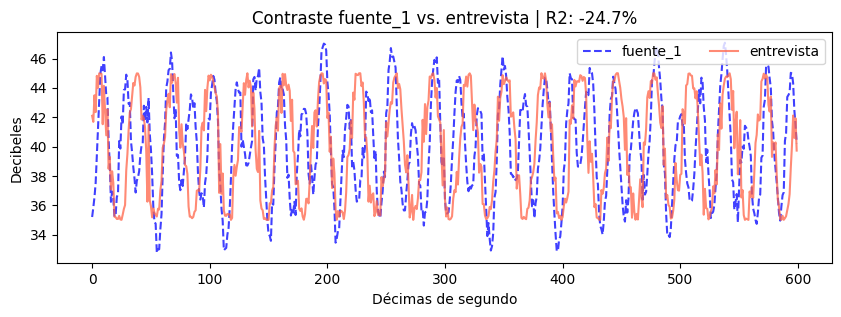

In [22]:
# Comparar fuente 1
fun_contraste(res_ica, "fuente_1")

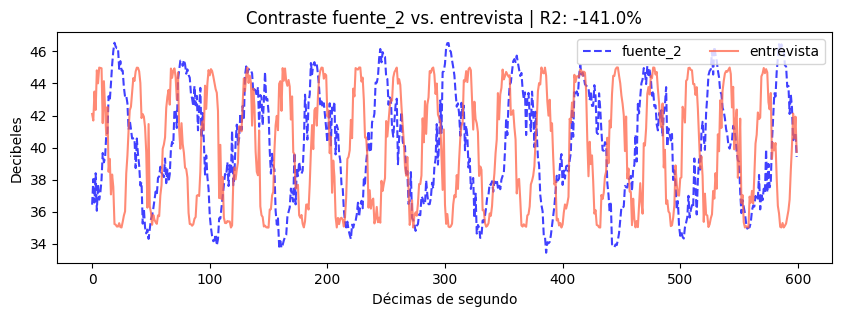

In [23]:
# Comparar fuente 2
fun_contraste(res_ica, "fuente_2")

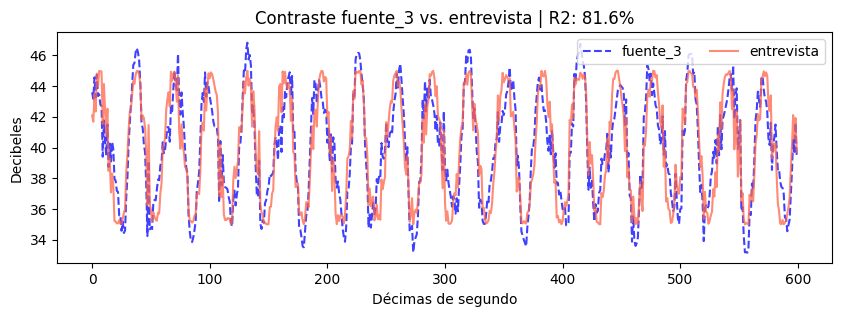

In [24]:
# Comparar fuente 3
fun_contraste(res_ica, "fuente_3")

De los resultados alcanzados se desprende que existe evidencia significativa de que el sospechoso participó de la reunión investigada por la Fiscalía. Por tanto, la entidad ya cuenta con insumos para preparar su caso contra esta persona gracias a tus habiidades en ciencia de datos y álgebra lineal. 

## ICA con Scikit-Learn

Para terminar, vale que conozcas la función `FastICA` de **Scikit-Learn** que implementa el algoritmo visto en este caso de manera automática. Aplícalo entonces con tus datos y mira los resultados alcanzados, que son incluso mejores a los vistos en el paso a paso anterior debido a que emplea métodos de optimización avanzados (por eso el nombre con "Fast").

In [25]:
# Cargar librería
from sklearn.decomposition import FastICA

# Crear modelo ICA
mod_ica = FastICA(max_iter = 1000, random_state = 123)

# Extraer componentes independientes
X_fica = mod_ica.fit_transform(df_reunion)
X_fica = pd.DataFrame(X_fica)
X_fica.columns = ["fuente_" + str(i+1) for i in range(len(df_reunion.columns))]

# Desescalar componentes
X_fica = X_fica * desviacion + media
X_fica.head()

,fuente_1,fuente_2,fuente_3
0,35.332521,42.038703,35.216188
1,35.612785,41.647163,36.923331
2,36.072429,43.431057,35.810605
3,36.939446,42.305780,37.805532
4,38.627322,44.732606,36.235549


In [26]:
# Incorporar datos de entrevista
res_fica = X_fica.copy().iloc[:600,:]
res_fica["entrevista"] = df_entrevista["db"]
res_fica.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fuente_1    600 non-null    float64
 1   fuente_2    600 non-null    float64
 2   fuente_3    600 non-null    float64
 3   entrevista  600 non-null    float64
dtypes: float64(4)
memory usage: 18.9 KB


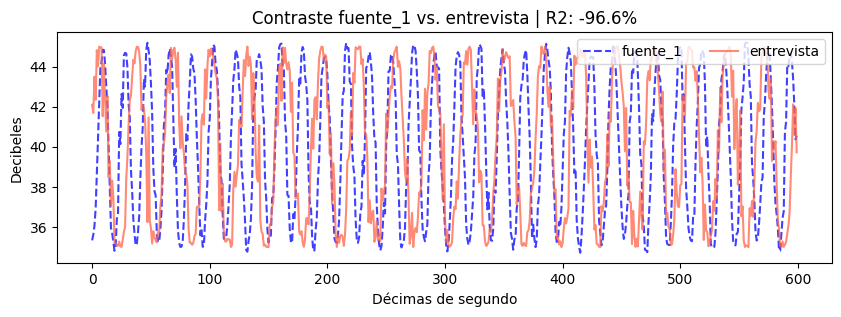

In [27]:
# Comparar fuente 1 (FastICA)
fun_contraste(res_fica, "fuente_1")

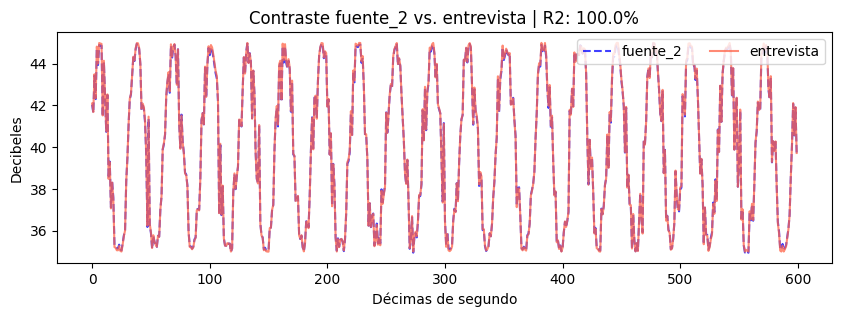

In [28]:
# Comparar fuente 2 (FastICA)
fun_contraste(res_fica, "fuente_2")

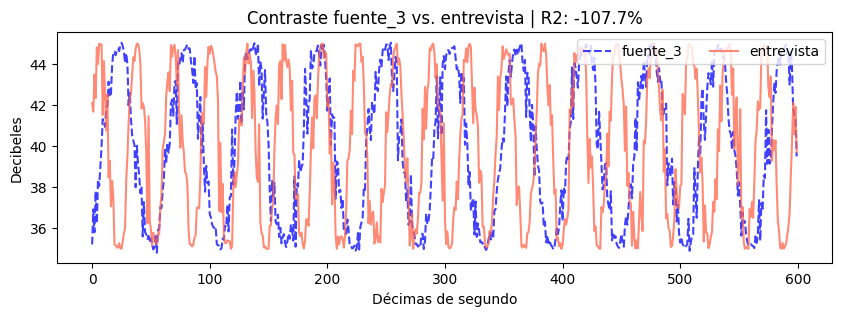

In [29]:
# Comparar fuente 3 (FastICA)
fun_contraste(res_fica, "fuente_3")